## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

!pip install torchtext==0.6.0
!pip install subword-nmt
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.6 MB/s eta 0:00:00


In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !curl -O https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.3M  100 12.3M    0     0  11.7M      0  0:00:01  0:00:01 --:--:-- 11.7M


#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:
!pip install spacy

In [4]:
# old deprecated code
import torch
import torch.nn as nn
import torch.optim as optim

import torchtext
from torchtext.datasets import TranslationDataset, Multi30k
from torchtext.data import Field, BucketIterator

import spacy

import random
import math
import time

import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [5]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [6]:
SRC = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

TRG = Field(tokenize=tokenize,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

dataset = torchtext.data.TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TRG), ('src', SRC)]
)

In [7]:
train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

In [8]:
print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500


In [9]:
SRC.build_vocab(train_data, min_freq = 3)
TRG.build_vocab(train_data, min_freq = 3)

In [10]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (ru) vocabulary: 9278
Unique tokens in target (en) vocabulary: 6689


Here are tokens from original (RU) corpus:

In [11]:
SRC.vocab.itos[::1000]

['<unk>',
 'многочисленных',
 'ват',
 'кондиционирования',
 'boulevard',
 'aurora',
 'miraflores',
 'тяньаньмэнь',
 'динар',
 'театром']

And from target (EN) corpus:

In [12]:
TRG.vocab.itos[::1000]

['<unk>', 'addition', 'chopin', 'bilbao', 'mühle', 'sonne', 'mahal']

And here is example from train dataset:

In [13]:
print(vars(train_data.examples[9]))

{'trg': ['spa', 'services', ',', 'including', 'massage', ',', 'can', 'also', 'be', 'arranged', '.'], 'src': ['по', 'запросу', 'в', 'отеле', 'проводят', 'спа', '-', 'и', 'массажные', 'процедуры', '.']}


Let's check the length distributions:

Length distribution in Train data


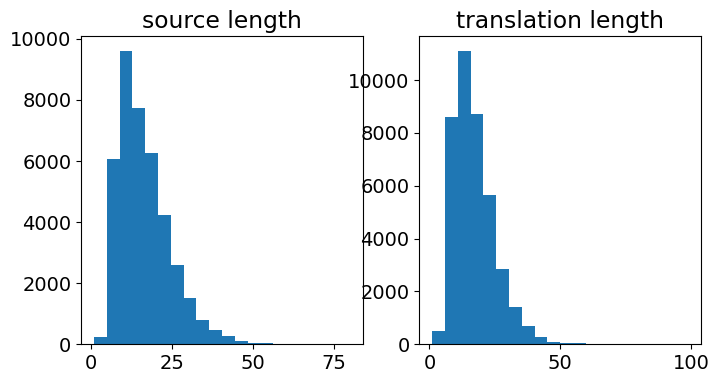

In [14]:
src_length = map(len, [vars(x)['src'] for x in train_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


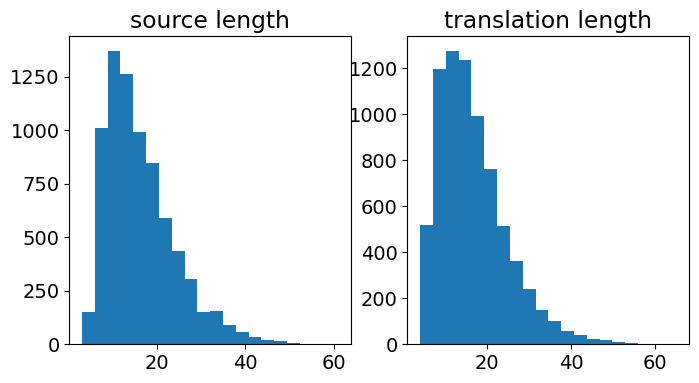

In [15]:
src_length = map(len, [vars(x)['src'] for x in test_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
device

device(type='cuda')

In [18]:
def _len_sort_key(x):
    return len(x.src)

BATCH_SIZE = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    device = device,
    sort_key=_len_sort_key
)

In [19]:
for x in train_iterator:
    break
print(x)
print(x.src.shape, x.trg.shape)


[torchtext.data.batch.Batch of size 128]
	[.trg]:[torch.cuda.LongTensor of size 42x128 (GPU 0)]
	[.src]:[torch.cuda.LongTensor of size 46x128 (GPU 0)]
torch.Size([46, 128]) torch.Size([42, 128])


In [20]:
import my_network
Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq

In [21]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [22]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9278, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(6689, 256)
    (rnn): LSTM(768, 512, num_layers=2, dropout=0.5)
    (out): Linear(in_features=1024, out_features=6689, bias=True)
    (attn_linear): Linear(in_features=1024, out_features=512, bias=True)
    (attn_v): Linear(in_features=512, out_features=1, bias=False)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 19,874,081 trainable parameters


In [24]:
PAD_IDX = TRG.vocab.stoi['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index = PAD_IDX)

In [25]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):

        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg)

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        #trg = [(trg sent len - 1) * batch size]
        #output = [(trg sent len - 1) * batch size, output dim]

        loss = criterion(output, trg)

        loss.backward()

        # Let's clip the gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        history.append(loss.cpu().data.numpy())
        if (i+1)%10==0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

            clear_output(True)
            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title('Train loss')
            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')
            plt.legend()

            plt.show()


    return epoch_loss / len(iterator)

In [26]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    history = []

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch.src
            trg = batch.trg

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg sent len, batch size]
            #output = [trg sent len, batch size, output dim]

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            #trg = [(trg sent len - 1) * batch size]
            #output = [(trg sent len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [27]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [28]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

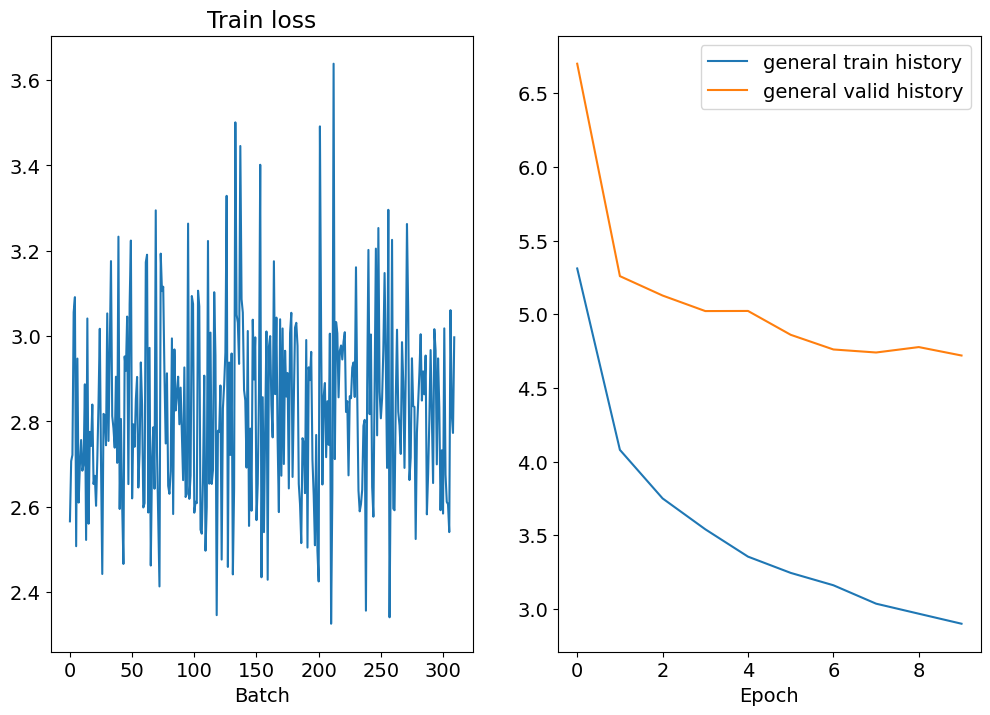

Epoch: 10 | Time: 2m 2s
	Train Loss: 2.824 | Train PPL:  16.849
	 Val. Loss: 4.760 |  Val. PPL: 116.706


In [ ]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

__Let's take a look at our network quality__:

In [ ]:
del utils

In [29]:
import utils
# import imp
# imp.reload(utils)
generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [30]:
batch = next(iter(test_iterator))

In [31]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

Original: the property offers free parking .
Generated: hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden

Original: the apartment will provide you with a tv .
Generated: hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden hidden



In [32]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [33]:
import tqdm

In [ ]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

59it [00:08,  6.63it/s]


In [ ]:
corpus_bleu([[text] for text in original_text], generated_text) * 100

15.490070855228902

Let's save this baseline BLEU and apply another approaches to improve this result



In [ ]:
baseline_bleu = 15.49
baseline_val_loss = 4.76

print(f"Baseline - BLEU: {baseline_bleu}, Val Loss: {baseline_val_loss}")

Baseline - BLEU: 15.49, Val Loss: 4.76


Let's add attention to our RNN model and retrain it

In [34]:
import importlib
import my_network
importlib.reload(my_network)
from my_network import Encoder, Decoder, Seq2Seq

In [35]:
def build_model(encoder_class, decoder_class, src_vocab, trg_vocab, device):

    INPUT_DIM = len(src_vocab)
    OUTPUT_DIM = len(trg_vocab)
    ENC_EMB_DIM = 256
    DEC_EMB_DIM = 256
    HID_DIM = 512
    N_LAYERS = 2
    ENC_DROPOUT = 0.3
    DEC_DROPOUT = 0.3

    enc = encoder_class(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
    dec = decoder_class(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

    model = Seq2Seq(enc, dec, device).to(device)
    return model

def train_model(model, train_iterator, valid_iterator, optimizer, criterion, n_epochs=10, clip=1, scheduler=None):

    train_history = []
    valid_history = []
    best_valid_loss = float('inf')

    for epoch in range(n_epochs):
        start_time = time.time()

        train_loss = train(model, train_iterator, optimizer, criterion, clip, train_history, valid_history)
        valid_loss = evaluate(model, valid_iterator, criterion)

        if scheduler is not None:
            scheduler.step(valid_loss)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model.pt')

        train_history.append(train_loss)
        valid_history.append(valid_loss)
        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

    return train_history, valid_history

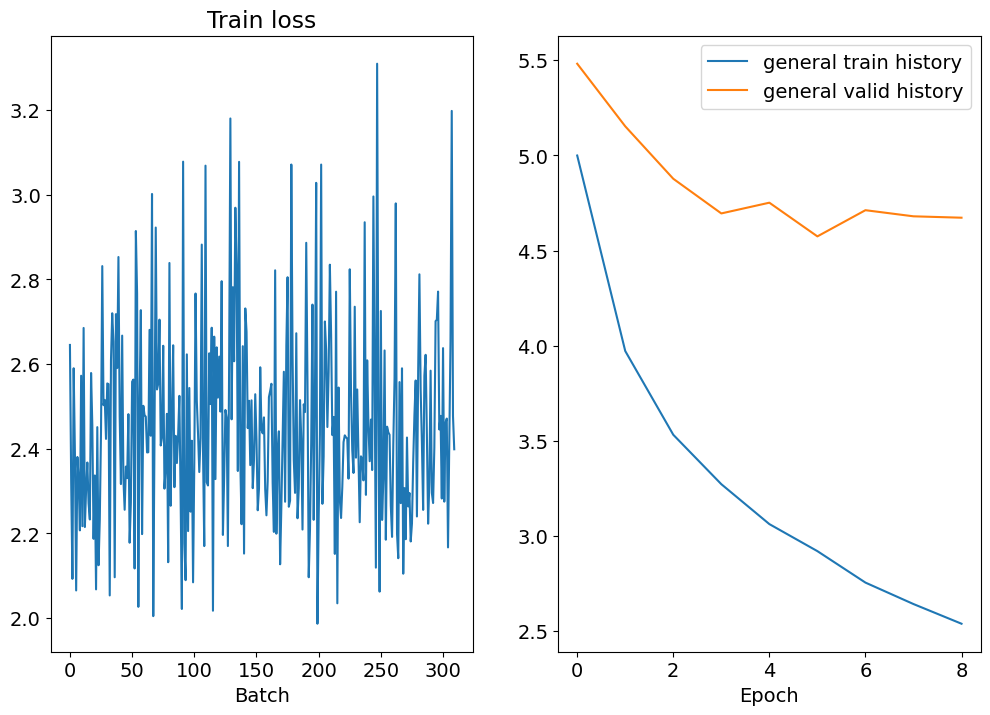

Epoch: 10 | Time: 2m 24s
	Train Loss: 2.456 | Train PPL:  11.657
	 Val. Loss: 4.559 |  Val. PPL:  95.513


In [ ]:
model_attention = build_model(Encoder, Decoder, SRC.vocab, TRG.vocab, device)

model_attention.apply(init_weights)

optimizer = optim.Adam(model_attention.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_history_att, valid_history_att = train_model(
    model_attention,
    train_iterator,
    valid_iterator,
    optimizer,
    criterion,
    n_epochs=10
)

In [ ]:
original_text = []
generated_text = []
model_attention.eval()

with torch.no_grad():
    for i, batch in enumerate(test_iterator):
        src = batch.src
        trg = batch.trg
        output = model_attention(src, trg, 0)
        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

attention_bleu = corpus_bleu([[text] for text in original_text], generated_text) * 100
print(f"Attention BLEU: {attention_bleu}")

Attention BLEU: 17.706293953430258


Now let's add Bahdanau attention and see the difference

In [36]:
import importlib
import my_network
importlib.reload(my_network)
from my_network import Encoder, Decoder, Seq2Seq

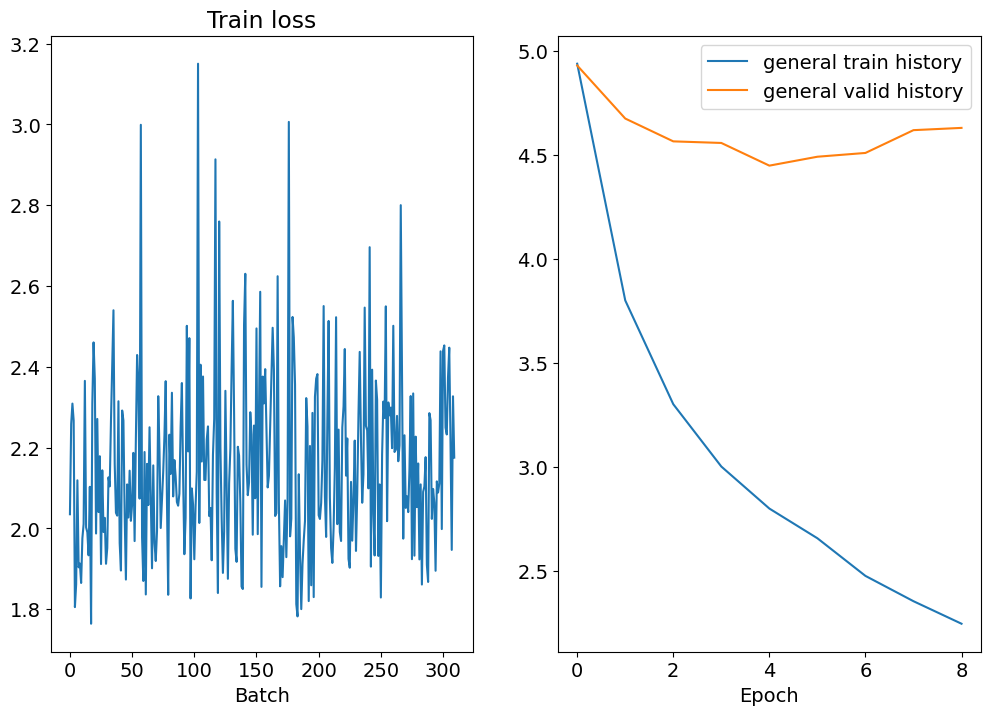

Epoch: 10 | Time: 4m 3s
	Train Loss: 2.157 | Train PPL:   8.645
	 Val. Loss: 4.476 |  Val. PPL:  87.904


In [ ]:
model_attention_bahdanau = build_model(Encoder, Decoder, SRC.vocab, TRG.vocab, device)

model_attention_bahdanau.apply(init_weights)

optimizer = optim.Adam(model_attention_bahdanau.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_history_att, valid_history_att = train_model(
    model_attention_bahdanau,
    train_iterator,
    valid_iterator,
    optimizer,
    criterion,
    n_epochs=10
)

In [ ]:
original_text = []
generated_text = []
model_attention_bahdanau.eval()

with torch.no_grad():
    for i, batch in enumerate(test_iterator):
        src = batch.src
        trg = batch.trg
        output = model_attention_bahdanau(src, trg, 0)
        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

attention_bleu = corpus_bleu([[text] for text in original_text], generated_text) * 100
print(f"Attention BLEU: {attention_bleu}")

Attention BLEU: 25.85900401864809


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model_attention_bahdanau):,} trainable parameters')

The model has 19,894,583 trainable parameters


As we can see Bahdanau attention works pretty good than just mean attention that gives us 17 on bleu and we decreased loss and perplexity. (The reason that it worked well is because for each word it computes it's own weight and it allows model to focus on important words)

Let's now improve this result using BPE

In [ ]:
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
import tempfile
import os

with open('ru_texts.txt', 'w') as f:
    for ex in train_data.examples:
        f.write(' '.join(ex.src) + '\n')

with open('en_texts.txt', 'w') as f:
    for ex in train_data.examples:
        f.write(' '.join(ex.trg) + '\n')

learn_bpe(open('ru_texts.txt'), open('ru_codes.txt', 'w'), 5000)
learn_bpe(open('en_texts.txt'), open('en_codes.txt', 'w'), 5000)

ru_bpe = BPE(open('ru_codes.txt'))
en_bpe = BPE(open('en_codes.txt'))

def tokenize_ru(x):
    return ru_bpe.process_line(x.lower()).split()

def tokenize_en(x):
    return en_bpe.process_line(x.lower()).split()

100%|██████████| 5000/5000 [00:03<00:00, 1412.17it/s]


In [ ]:
SRC = Field(tokenize=tokenize_ru, init_token='<sos>', eos_token='<eos>', lower=True)
TRG = Field(tokenize=tokenize_en, init_token='<sos>', eos_token='<eos>', lower=True)

In [ ]:
dataset = torchtext.data.TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TRG), ('src', SRC)]
)

train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

SRC.build_vocab(train_data, min_freq = 3)
TRG.build_vocab(train_data, min_freq = 3)

print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

def _len_sort_key(x):
    return len(x.src)

BATCH_SIZE = 64

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    device = device,
    sort_key=_len_sort_key
)

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500
Unique tokens in source (ru) vocabulary: 4987
Unique tokens in target (en) vocabulary: 4901


In [ ]:
print(f"Source vocab size (BPE): {len(SRC.vocab)}")
print(f"Target vocab size (BPE): {len(TRG.vocab)}")
print("BPE token examples:", SRC.vocab.itos[:20])

Source vocab size (BPE): 4987
Target vocab size (BPE): 4901
BPE token examples: ['<unk>', '<pad>', '<sos>', '<eos>', '.', 'в', 'и', ',', '-@@', 'с', 'м@@', 'на', 'от', 'к@@', 'до', 'гостей', 'для', 'а', 'находится', 'к']


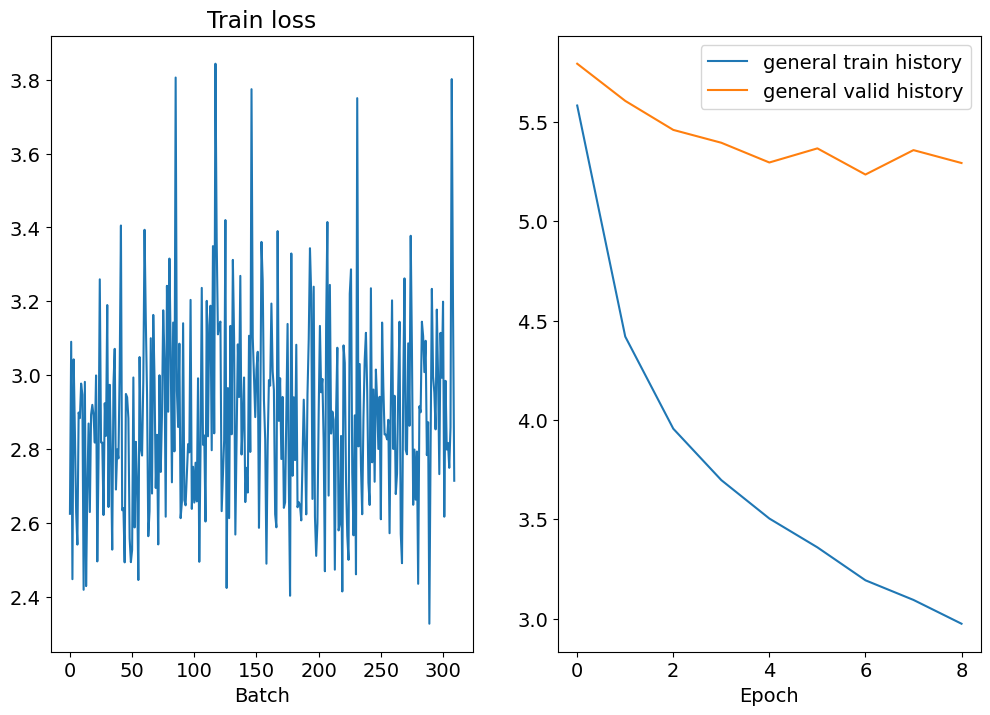

Epoch: 10 | Time: 5m 45s
	Train Loss: 2.885 | Train PPL:  17.907
	 Val. Loss: 5.271 |  Val. PPL: 194.701


In [ ]:
model_bpe = build_model(Encoder, Decoder, SRC.vocab, TRG.vocab, device)
model_bpe.apply(init_weights)

optimizer = optim.Adam(model_bpe.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_history_bpe, valid_history_bpe = train_model(
    model_bpe,
    train_iterator,
    valid_iterator,
    optimizer,
    criterion,
    n_epochs=10
)

Looking on perplexity of this model it seems like its less confident in choosing next token. Possible reason for dropping bleu from 25 to 22 is maybe it requires more epochs to converge and learning rate may need some adjustments

In [ ]:
original_text = []
generated_text = []
model_bpe.eval()

with torch.no_grad():
    for i, batch in enumerate(test_iterator):
        src = batch.src
        trg = batch.trg
        output = model_bpe(src, trg, 0)
        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

attention_bleu = corpus_bleu([[text] for text in original_text], generated_text) * 100
print(f"BPE BLEU: {attention_bleu}")

BPE BLEU: 22.729339219994625


P.S: Unfortunately, collab crashed in training process, but i decided to keep it here, maybe will try it later

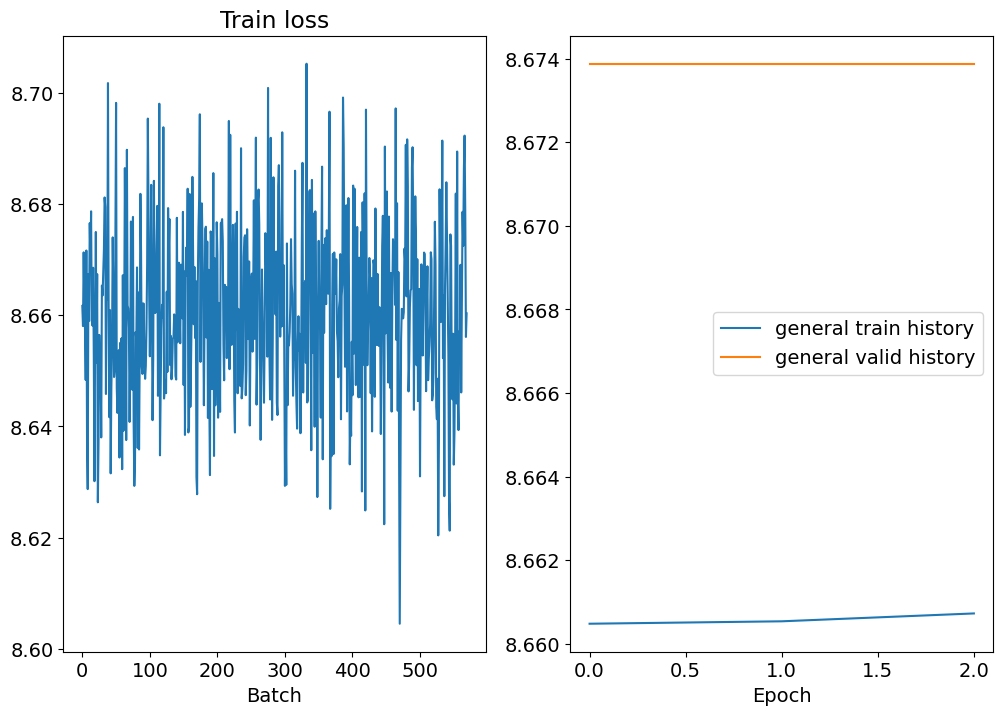

In [ ]:
import importlib
import my_network
importlib.reload(my_network)

from my_network import TransformerEncoder, TransformerDecoder, Seq2SeqTransformer

enc = TransformerEncoder(len(SRC.vocab), emb_dim=128, hid_dim=256, n_layers=2, dropout=0.1)
dec = TransformerDecoder(len(TRG.vocab), emb_dim=128, hid_dim=256, n_layers=2, dropout=0.1)
model_transformer = Seq2SeqTransformer(enc, dec, device).to(device)

train_model(model_transformer, train_iterator, valid_iterator, optimizer, criterion, n_epochs=5)

In [ ]:
import importlib
import my_network
importlib.reload(my_network)
from my_network import Encoder, Decoder, Seq2Seq

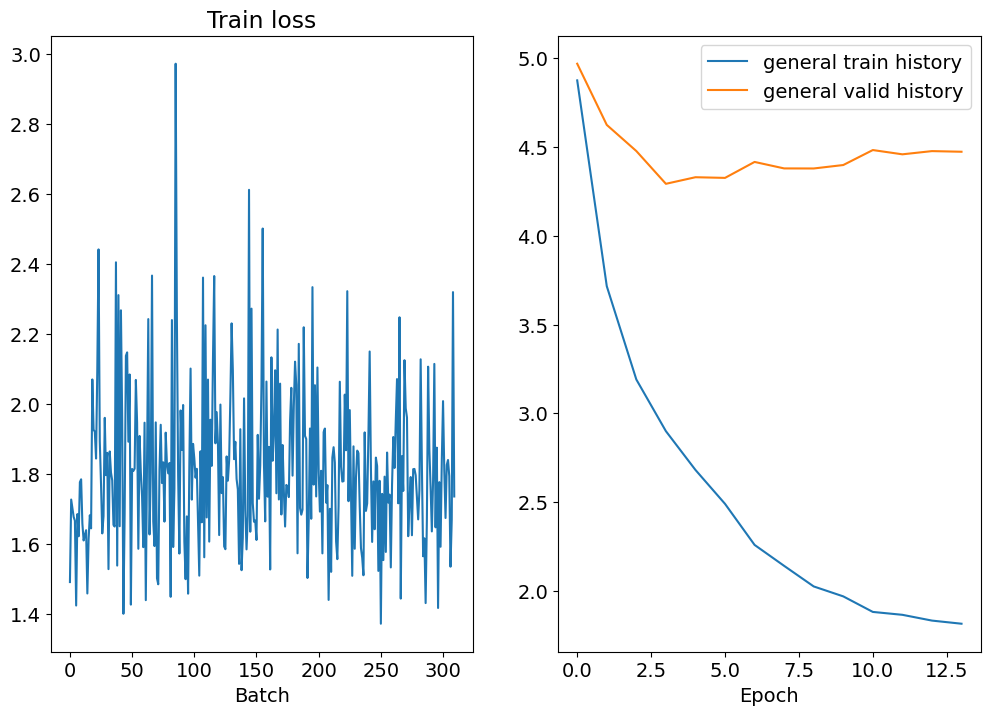

Epoch: 15 | Time: 4m 1s
	Train Loss: 1.813 | Train PPL:   6.126
	 Val. Loss: 4.486 |  Val. PPL:  88.800


In [37]:
model_attention_opt = build_model(Encoder, Decoder, SRC.vocab, TRG.vocab, device)

model_attention_opt.apply(init_weights)

optimizer = optim.Adam(model_attention_opt.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

train_history_att, valid_history_att = train_model(
    model_attention_opt,
    train_iterator,
    valid_iterator,
    optimizer,
    criterion,
    n_epochs=15,
    scheduler=scheduler
)

In [39]:
original_text = []
generated_text = []
model_attention_opt.eval()

with torch.no_grad():
    for i, batch in enumerate(test_iterator):
        src = batch.src
        trg = batch.trg
        output = model_attention_opt(src, trg, 0)
        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

attention_bleu = corpus_bleu([[text] for text in original_text], generated_text) * 100
print(f"with lr scheduler BLEU: {attention_bleu}")

with lr scheduler BLEU: 27.634043621657145


In [40]:
print("="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Model: RNN + Bahdanau Attention + BPE + LR Scheduler")
print(f"Test BLEU: {attention_bleu:.2f}")
print(f"Test Loss: {valid_history_att[-1]:.3f}" if 'valid_history_att' in dir() else "")

FINAL RESULTS
Model: RNN + Bahdanau Attention + BPE + LR Scheduler
Test BLEU: 27.63
Test Loss: 4.486


Conclusions:
The model successfully achieved the target 27 BLEU

What improvements improvements contributed significantly:

Bahdanau attention: +10 BLEU (where getting only mean over words gave us +2 bleu)

LR scheduler: stabilized training and using it with attention gave us +2 bleu


